<a href="https://colab.research.google.com/github/eospgonz10/statistical_analytics_homicide/blob/main/sesiones_practicas/sp_2_juan_jose_garcia_alvarez_estiven_ospina_gonzalez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 2: Análisis Univariado, bivariado y multivariado</strong></span>


## <span style="color:black;"><strong>Datos de los estudiantes</strong></span>

In [ ]:
nombre = input("📝 Ingresa tu nombre completo: ")
correo = input("📧 Ingresa tu correo electrónico: ")
cedula = input("🔢 Ingresa los últimos 6 dígitos de tu cédula: ")

📝 Ingresa tu nombre completo: Estiven Ospina González
📧 Ingresa tu correo electrónico: estiven.ospinag@udea.edu.co
🔢 Ingresa los últimos 6 dígitos de tu cédula: 711784


## <span style="color:black;"><strong>Parte 1: Análisis Univariado</strong></span>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>

A partir de una muestra simulada de ingresos, calcula la **media, mediana y moda**, y luego a interpretarlas.

1. Usa el número base `528310` (debes reemplazarlo con los últimos 6 dígitos de tu documento de identificación).  
2. Con este número genera una semilla (`np.random.seed`) para que los resultados sean reproducibles.  
3. Los ingresos se simulan con una distribución normal:  
   - Media teórica: `(base % 10) + 2`  
   - Desviación estándar: `2`  
   - Tamaño de muestra: `30`  
4. Los valores negativos se reemplazan por cero (pues los ingresos no pueden ser negativos).  
5. Grafica tus resultados (ver imagen de ejemplo)

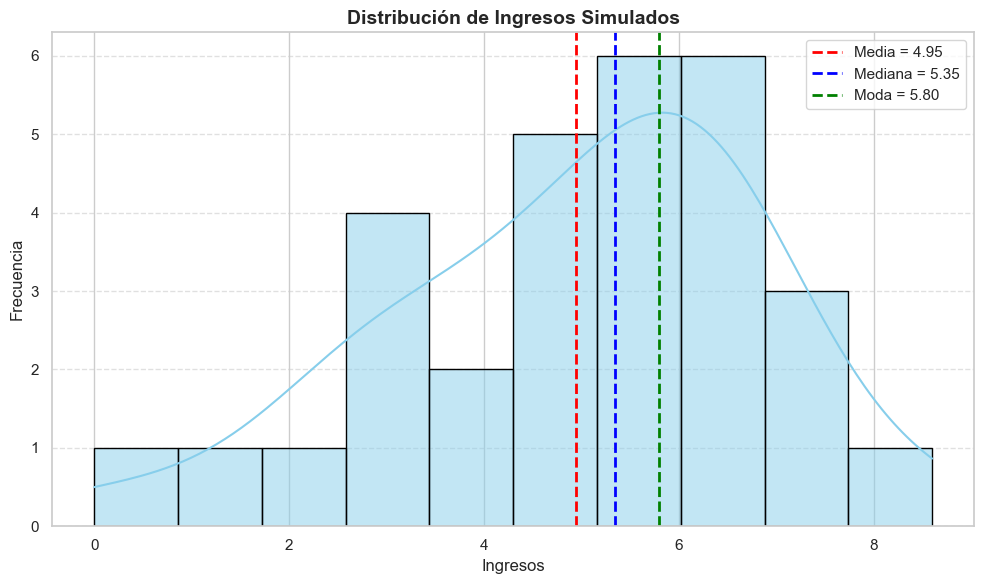

####Medidas de tendencia cental




In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

semilla = int(cedula)
np.random.seed(semilla)

media_proyectada = (semilla % 10 ) + 2
dstd = 2
numero_elementos = 30

simulacion_proyectada = np.random.normal(media_proyectada, dstd, numero_elementos)

media = np.mean(simulacion_proyectada)
mediana = np.median(simulacion_proyectada)
moda = stats.mode(simulacion_proyectada, keepdims=True)[0][0]

print(simulacion_proyectada)
# Resultados
print("Medidas de tendencia central:")
print(f"Media:   {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda:    {moda:.2f}")

[4.91327914 4.4004927  6.02932258 4.10380645 6.63260745 5.83444583
 5.59931614 3.10799007 6.09091203 3.69721691 5.79180377 8.17237358
 6.92274764 7.07644377 4.01979194 3.62210651 6.73545717 5.47079957
 5.11754597 5.85567833 4.59597181 6.60028404 5.09541461 4.16935875
 5.49584375 6.77524929 4.34608702 8.21387946 3.2863411  6.2261994 ]
Medidas de tendencia central:
Media:   5.47
Mediana: 5.55
Moda:    3.11


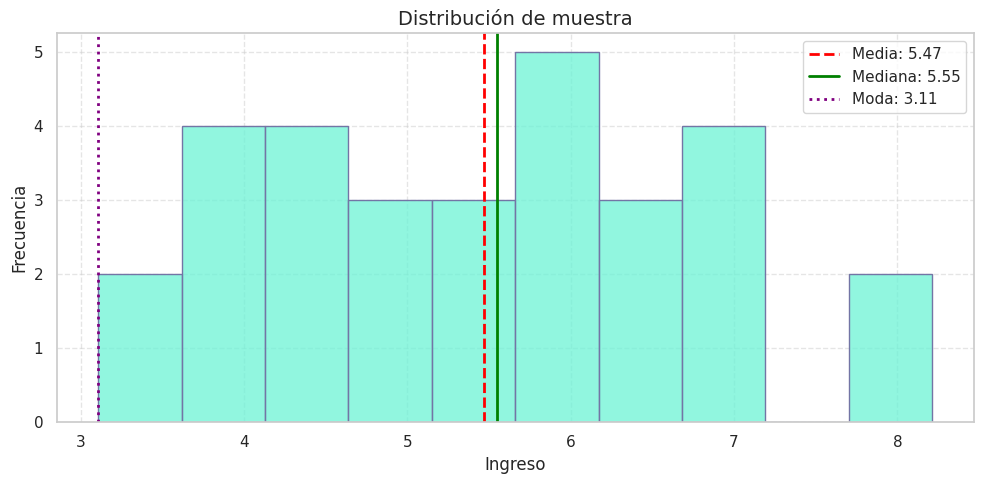

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(simulacion_proyectada, bins=10, kde=False, color="#6cf3d5", edgecolor = '#7375a5')

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

plt.title("Distribución de muestra", fontsize=14)
plt.xlabel("Ingreso", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**La media y la mediana son muy similares**
Esto indica que la distribución es *bastante simétrica* respecto a la media. Cuando media ≈ mediana, normalmente no hay un sesgo fuerte hacia la derecha o izquierda.
1.   **Media**: Aunque la media proyectada era 6, la muestra dio ≈ 5.47.
Esto ocurre porque:

Es una muestra pequeña (n=30)

Existe variabilidad aleatoria en la simulación

2.   **Moda**: No es muy representativa, La gráfica muestra: Moda ≈ 3.11

En datos continuos simulados con distribución normal: Es muy raro que haya valores repetidos exactos.

'stats.mode()' en variables continuas no suele ser una buena medida.


Esa “moda” realmente es solo el valor mínimo repetido o el primero detectado.

En distribuciones normales continuas, la moda teórica debería coincidir con la media (≈ 6).

***Conclusión final***:
La gráfica muestra una distribución *aproximadamente normal*, centrada alrededor de 5.5–6, con dispersión moderada.

Las diferencias entre la media teórica (6) y la observada (5.47) se deben al tamaño de muestra relativamente pequeño.

Si aumentara numero_elementos a 1000 o más, observaría probablemente:

Media más cercana a 6

Mediana más cercana a 6

Histograma más suave y simétrico




### <span style="color:#2F749F;"><strong>Ejercicio 2: Cálculo de medidas de dispersión</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza qué tan dispersos están los datos respecto a su media. Calcula:
1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos (ver imagen de ejemplo)

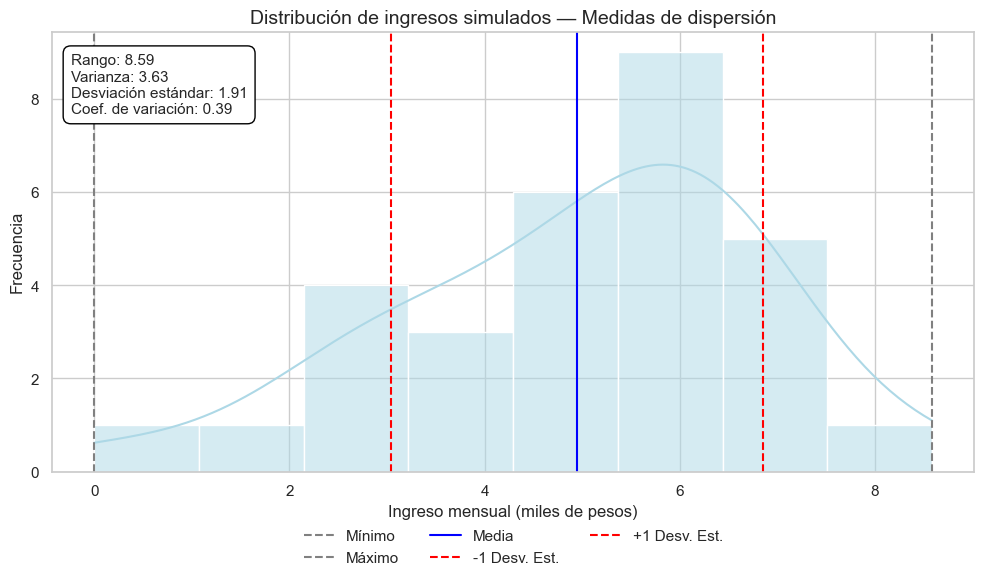

####Cálculo de medidas de dispersión

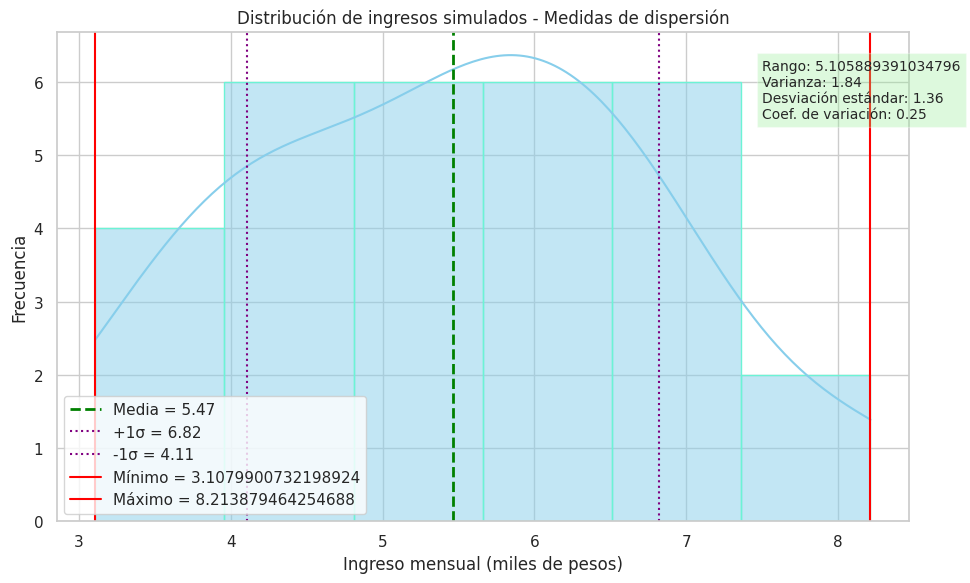

In [ ]:
# Cálculo de medidas de dispersión
minimo = np.min(simulacion_proyectada)
maximo = np.max(simulacion_proyectada)
rango = maximo - minimo
varianza = np.var(simulacion_proyectada, ddof=1)
desviacion = np.std(simulacion_proyectada, ddof=1)
coef_var = desviacion / media

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(simulacion_proyectada, bins=6, kde=True, color='skyblue', edgecolor = '#6cf3d5')

plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("Distribución de ingresos simulados - Medidas de dispersión")
plt.xlabel("Ingreso mensual (miles de pesos)")
plt.ylabel("Frecuencia")
plt.legend()

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
plt.text(7.5, 5.5, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()


### <span style="color:#2F749F;"><strong>Ejercicio 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal (ver la imagen de ejemplo)

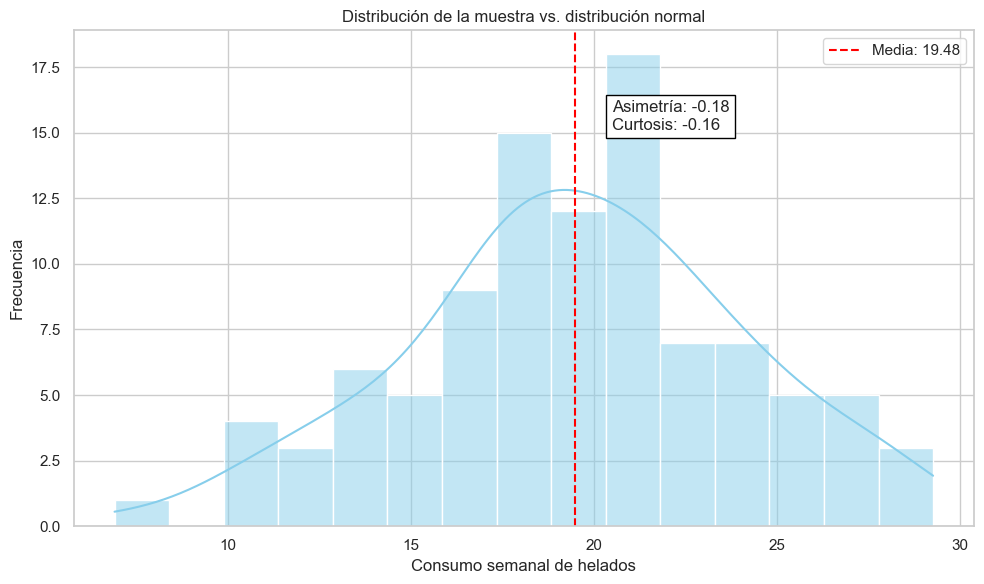


####Medidas de distribución

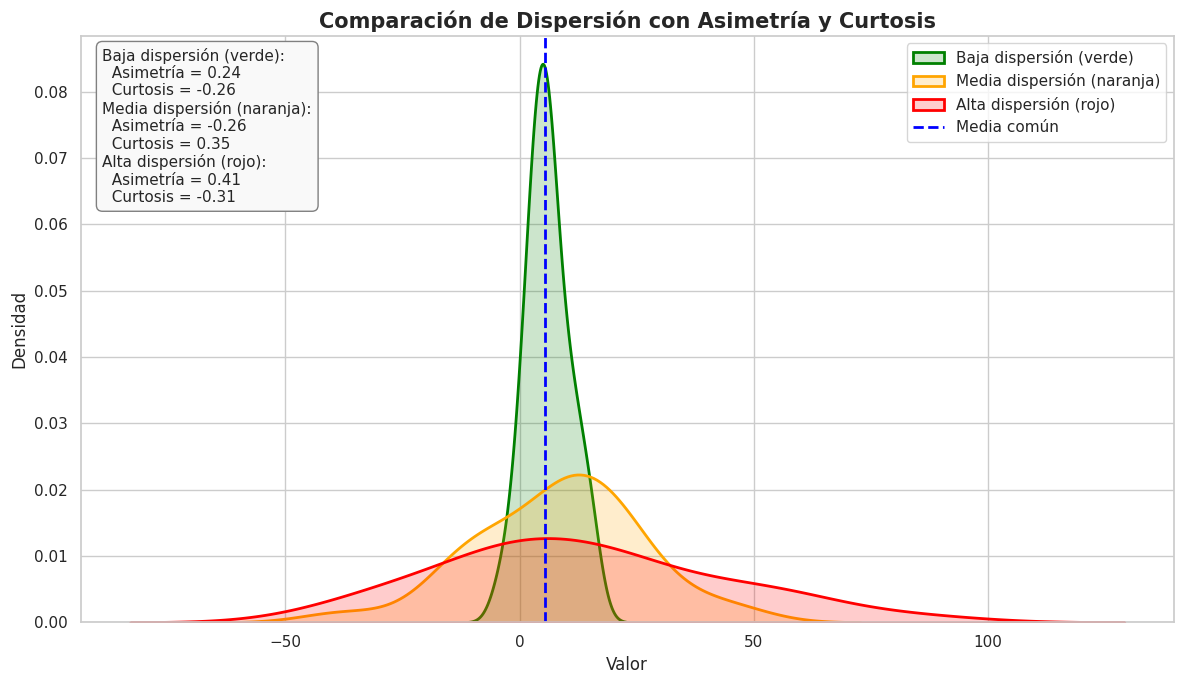

In [ ]:
sns.set_theme(style="whitegrid")

# Simulación de tres distribuciones con distinta dispersión
baja = np.random.normal(loc=media, scale=5, size=numero_elementos)
media_disp = np.random.normal(loc=media, scale=15, size=numero_elementos)
alta = np.random.normal(loc=media, scale=30, size=numero_elementos)

# Cálculo de métricas
metrics = {
    'Baja dispersión (verde)': {'data': baja, 'color': 'green'},
    'Media dispersión (naranja)': {'data': media_disp, 'color': 'orange'},
    'Alta dispersión (rojo)': {'data': alta, 'color': 'red'}
}

for key in metrics:
    datos = metrics[key]['data']
    metrics[key]['skew'] = skew(datos)
    metrics[key]['kurtosis'] = kurtosis(datos)

# Visualización
plt.figure(figsize=(12, 7))
for key in metrics:
    datos = metrics[key]['data']
    color = metrics[key]['color']
    sns.kdeplot(datos, label=f'{key}', color=color, linewidth=2, fill=True, alpha=0.2)

plt.axvline(media, color='blue', linestyle='--', linewidth=2, label='Media común')

# Anotaciones
texto = "\n".join([
    f"{key}:\n  Asimetría = {metrics[key]['skew']:.2f}\n  Curtosis = {metrics[key]['kurtosis']:.2f}"
    for key in metrics
])
plt.text(0.02, 0.98, texto, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor='#f9f9f9', edgecolor="gray"))

plt.title('Comparación de Dispersión con Asimetría y Curtosis', fontsize=15, fontweight='bold')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


### <span style="color:#2F749F;"><strong>Ejercicio 4: Cálculo de medidas de percentiles</strong></span>

A partir de la muestra generada en el Ejercicio 1, calcula los percentiles de tus datos. Calcula:
1. Percentiles
2. Deciles
3. Cuartiles
4. Grafica los anteriores percentiles calculados, sobre la distribución de tus datos (ver la imagen de ejemplo)

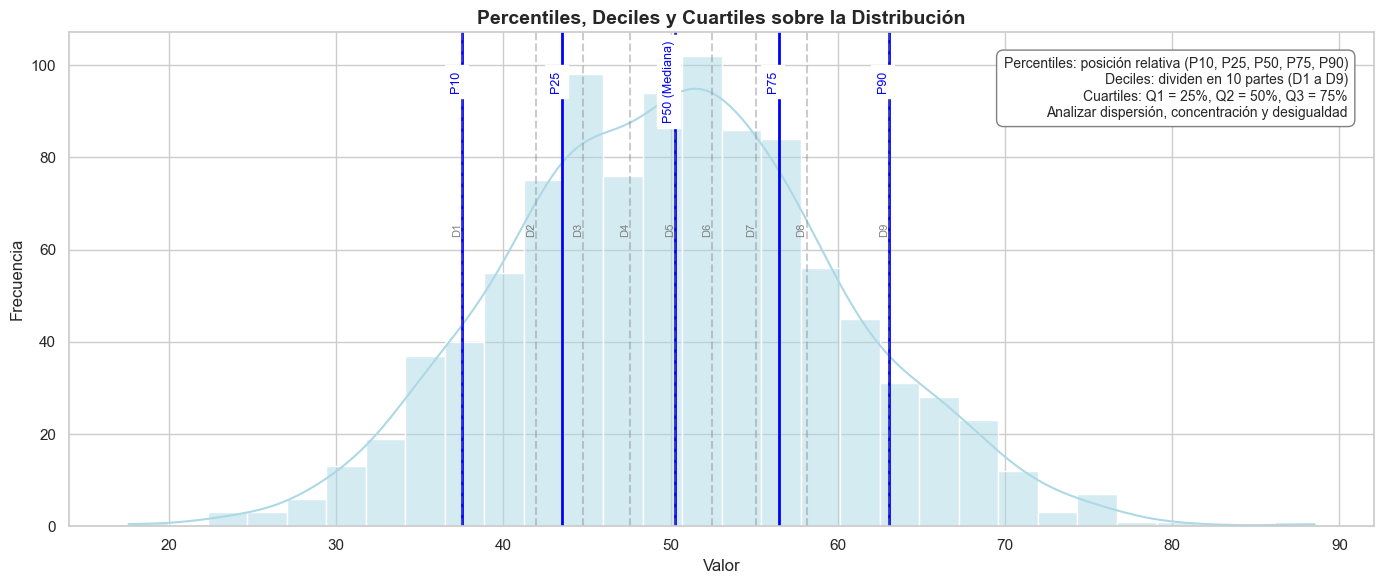

####Medidas de percentiles

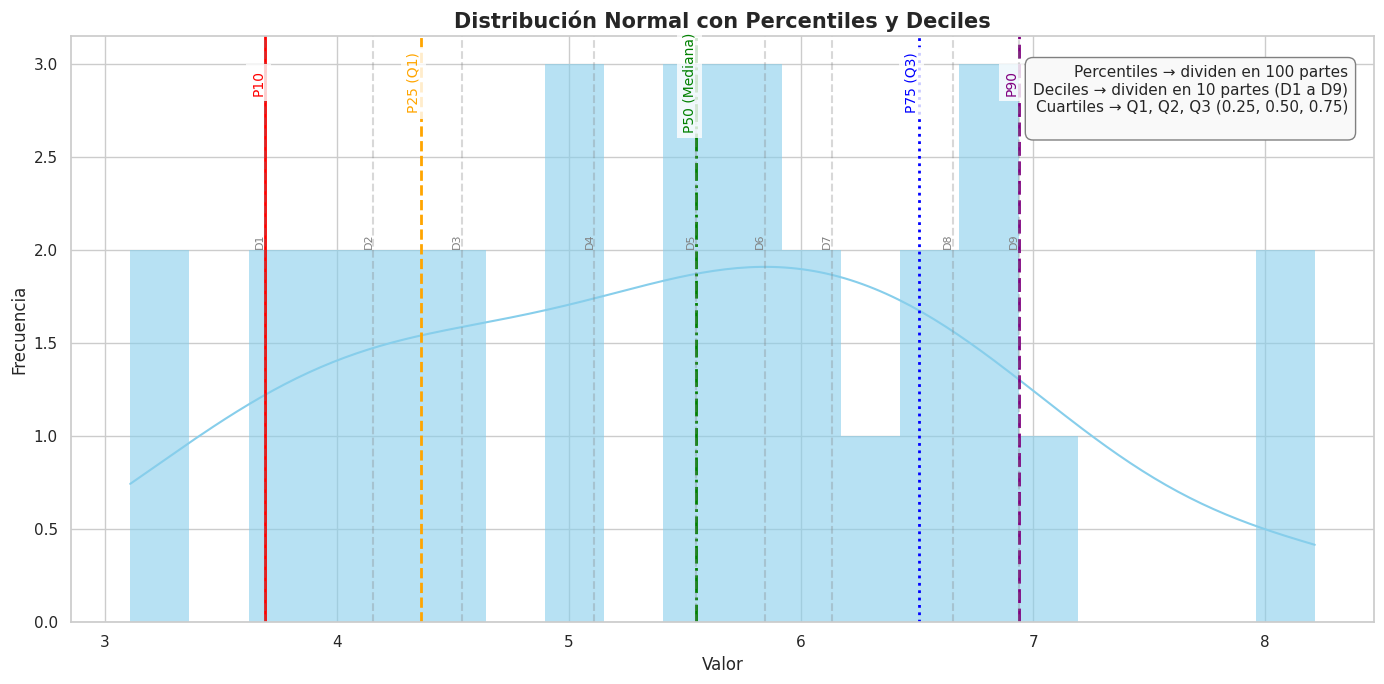

In [ ]:
# Estilo visual
sns.set_theme(style="whitegrid")


# Cálculo de percentiles clave
percentiles = {
    'P10': {'valor': np.percentile(simulacion_proyectada, 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(simulacion_proyectada, 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(simulacion_proyectada, 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(simulacion_proyectada, 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(simulacion_proyectada, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}

# Cálculo de deciles (D1 a D9)
deciles = {f'D{i}': np.percentile(simulacion_proyectada, i * 10) for i in range(1, 10)}

# Visualización
plt.figure(figsize=(14, 7))
sns.histplot(simulacion_proyectada, kde=True, color='skyblue', bins=20, edgecolor="None", alpha=0.6)

# Líneas verticales de percentiles
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
    plt.text(props['valor'], plt.ylim()[1]*0.92, etiqueta,
             rotation=90, color=props['color'], fontsize=10,
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Líneas verticales de deciles
for etiqueta, valor in deciles.items():
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.3)
    plt.text(valor, plt.ylim()[1]*0.65, etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='right')

texto = (
    "Percentiles → dividen en 100 partes\n"
    "Deciles → dividen en 10 partes (D1 a D9)\n"
    "Cuartiles → Q1, Q2, Q3 (0.25, 0.50, 0.75)\n")
plt.text(0.98, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f9f9f9", edgecolor="gray"))

plt.title("Distribución Normal con Percentiles y Deciles", fontsize=15, fontweight='bold')
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## <span style="color:black;"><strong>Parte 2: Análisis Bivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 5: Análisis de correlación</strong></span>

En esta segunda parte, genera **dos variables** a partir de tú número de cédula y realiza un análisis **bivariado** para calcular la relación entre ellas.

1. Use los **6 últimos dígitos** de su cédula como base (similar al Ejercicio 1).  
2. Genere dos variables aleatorias (ejemplo: `ingresos` y `gastos`) con distribución normal, usando esa base como **semilla reproducible**.  
3. Calcule los coeficientes de correlación de **Pearson** y **Spearman**.
4. Grafique las variables analizadas (ver la imagen de ejemplo)
5. Interprete los resultados.  

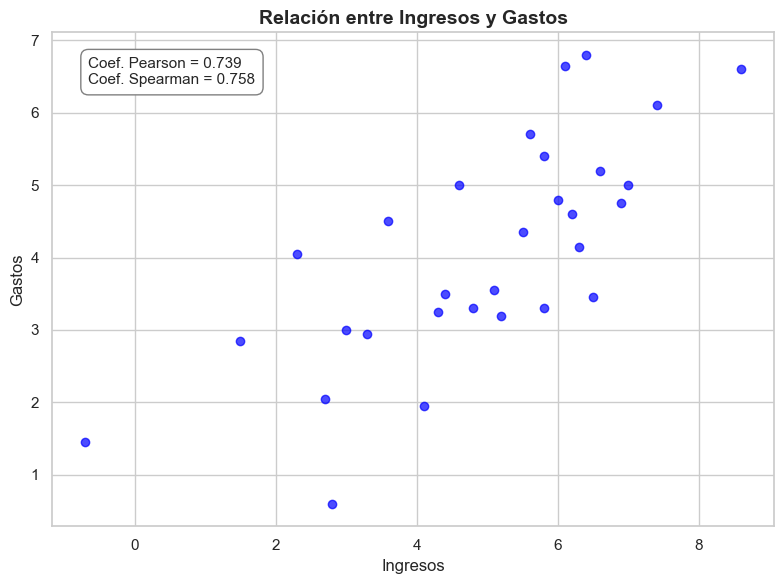

### <span style="color:#2F749F;"><strong>Ejercicio 6: Chi-Cuadrado</strong></span>

En esta parte, analiza si existe **asociación estadística** entre dos variables categóricas simuladas a partir de tu número de cédula.

1. Usa los **6 últimos dígitos** de tu cédula como base para generar una semilla reproducible.
2. Simula una muestra de **60 personas** con dos variables categóricas:
   - `Nivel educativo`: Básico, Medio, Superior.
   - `Acceso a internet`: Sí, No.
3. Crea una **tabla de contingencia** entre ambas variables.
4. Aplica la **prueba de Chi cuadrado de independencia**.
5. Visualiza la distribución conjunta con un mapa de calor (ver la imagen de con la información de ejemplo).
6. Interpreta el resultado.

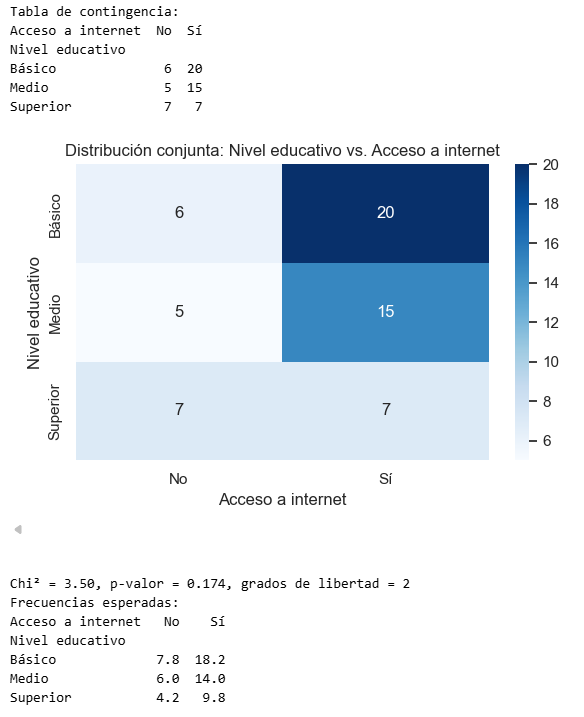